# CS221M — Figure 2 Reproduction (Colab)

Reproduces Figure 2 from Geva et al. (2023),
[*Dissecting Recall of Factual Associations in Auto-Regressive Language Models*](https://arxiv.org/abs/2304.14767).

**Before running:** `Runtime → Change runtime type → T4 GPU`. Then `Runtime → Run all`.

Estimated wall time:
- `gpt2` (12 layers): ~1 min on T4, ~3 min on CPU
- `gpt2-medium` (24 layers): ~5–10 min on T4
- `gpt2-large` (36 layers): ~20 min on T4

In [1]:
!pip install -q "transformers==4.36.2"

## 1. Environment check

In [2]:
import torch, transformers, sys
print("Python:      ", sys.version.split()[0])
print("PyTorch:     ", torch.__version__)
print("Transformers:", transformers.__version__)
print("CUDA:        ", torch.cuda.is_available(),
      "—", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")

/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

Python:       3.12.13
PyTorch:      2.10.0+cu128
Transformers: 4.36.2
CUDA:         True — Tesla T4


## 2. Configuration

In [3]:
# Pick a model. Smaller = faster but pattern is noisier.
MODEL_NAME = "gpt2-medium"   # "gpt2" | "gpt2-medium" | "gpt2-large" | "gpt2-xl"

# Window of layers around each center layer to knock out (paper uses 9 for GPT-2 XL).
# `None` => scale proportionally with depth.
WINDOW = None

## 3. Factual prompts
Filtered at runtime to ones the model already predicts correctly.

In [4]:
QUERIES = [
    # (subject_string, prompt, expected_first_answer_token)
    ("Eiffel Tower",       "The Eiffel Tower is located in the city of",        " Paris"),
    ("Big Ben",            "Big Ben is located in the city of",                 " London"),
    ("Statue of Liberty",  "The Statue of Liberty is located in the city of",   " New"),
    ("Colosseum",          "The Colosseum is located in the city of",           " Rome"),
    ("Kremlin",            "The Kremlin is located in the city of",             " Moscow"),
    ("Acropolis",          "The Acropolis is located in the city of",           " Athens"),
    ("Albert Einstein",    "Albert Einstein was born in the country of",        " Germany"),
    ("Isaac Newton",       "Isaac Newton was born in the country of",           " England"),
    ("Leonardo da Vinci",  "Leonardo da Vinci was born in the country of",      " Italy"),
    ("Napoleon",           "Napoleon was born in the country of",               " France"),
    ("Mozart",             "Mozart was born in the country of",                 " Austria"),
    ("William Shakespeare","William Shakespeare was born in the country of",    " England"),
    ("Pablo Picasso",      "Pablo Picasso was born in the country of",          " Spain"),
    ("Marie Curie",        "Marie Curie was born in the country of",            " Poland"),
    ("Galileo Galilei",    "Galileo Galilei was born in the country of",        " Italy"),
    ("Sigmund Freud",      "Sigmund Freud was born in the country of",          " Austria"),
    ("Mahatma Gandhi",     "Mahatma Gandhi was born in the country of",         " India"),
    ("Microsoft",          "Microsoft was founded by Bill",                     " Gates"),
    ("Apple Inc.",         "Apple Inc. was founded by Steve",                   " Jobs"),
    ("Amazon",             "Amazon was founded by Jeff",                        " Bezos"),
    ("Facebook",           "Facebook was founded by Mark",                      " Zuckerberg"),
    ("Tesla Inc.",         "Tesla Inc. was founded by Elon",                    " Musk"),
    ("Toyota",             "Toyota is a company from the country of",           " Japan"),
    ("BMW",                "BMW is a company from the country of",              " Germany"),
    ("Ferrari",            "Ferrari is a company from the country of",          " Italy"),
    ("Samsung",            "Samsung is a company from the country of",          " South"),
]
print(f"{len(QUERIES)} prompts total")

26 prompts total


## 4. Knockout machinery

Wraps each layer's `GPT2Attention._attn` so that — when the global `STATE` says
so — a `-inf` bias is added to specific (query_pos, key_pos) cells, zeroing
those attention edges after softmax.

In [5]:
import torch.nn.functional as F
from transformers import GPT2LMHeadModel, GPT2TokenizerFast

class KnockoutState:
    def __init__(self):
        self.enabled = False
        self.layers = set()
        self.source_pos = None
        self.blocked_targets = []

STATE = KnockoutState()

def _make_patched_attn(original_attn, layer_idx):
    def patched(query, key, value, attention_mask=None, head_mask=None):
        if STATE.enabled and layer_idx in STATE.layers:
            b, _, q_len, _ = query.shape
            k_len = key.shape[-2]
            extra = torch.zeros((b, 1, q_len, k_len),
                                dtype=query.dtype, device=query.device)
            neg_inf = torch.finfo(query.dtype).min
            src = STATE.source_pos
            for tgt in STATE.blocked_targets:
                if 0 <= src < q_len and 0 <= tgt < k_len:
                    extra[:, :, src, tgt] = neg_inf
            attention_mask = extra if attention_mask is None else attention_mask + extra
        return original_attn(query, key, value, attention_mask, head_mask)
    return patched

def install_knockout(model):
    for i, block in enumerate(model.transformer.h):
        attn = block.attn
        # Check if _attn exists, otherwise try _attention (common refactor in transformers)
        original_method_name = None
        if hasattr(attn, "_attn"):
            original_method_name = "_attn"
        elif hasattr(attn, "_attention"):
            original_method_name = "_attention"
        else:
            raise AttributeError(
                f"GPT2Attention object in layer {i} has neither '_attn' nor '_attention' attribute to patch."
            )

        if not hasattr(attn, "_attn_original"):
            setattr(attn, "_attn_original", getattr(attn, original_method_name))

        # Replace the active attention method
        setattr(attn, original_method_name, _make_patched_attn(getattr(attn, "_attn_original"), i))

def prob_of(model, input_ids, target_token_id):
    with torch.no_grad():
        logits = model(input_ids).logits
    return F.softmax(logits[0, -1], dim=-1)[target_token_id].item()

def find_subject_positions(tokenizer, prompt, subject):
    full = tokenizer(prompt, add_special_tokens=False).input_ids
    for cand in [tokenizer(subject, add_special_tokens=False).input_ids,
                 tokenizer(" " + subject, add_special_tokens=False).input_ids]:
        n = len(cand)
        if n == 0:
            continue
        for i in range(len(full) - n + 1):
            if full[i:i + n] == cand:
                return list(range(i, i + n))
    return [0]

print("Knockout machinery defined.")

/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


Knockout machinery defined.


/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


## 5. Load model & filter prompts to the ones it predicts correctly

In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Loading {MODEL_NAME} on {device}...")
tokenizer = GPT2TokenizerFast.from_pretrained(MODEL_NAME)
model = GPT2LMHeadModel.from_pretrained(MODEL_NAME).to(device)
model.eval()
install_knockout(model)
n_layers = model.config.n_layer
print(f"  layers={n_layers}, heads/layer={model.config.n_head}")

correct = []
for subj, prompt, ans in QUERIES:
    ids = tokenizer(prompt, return_tensors="pt").input_ids.to(device)
    with torch.no_grad():
        pred = model(ids).logits[0, -1].argmax().item()
    ans_tok = tokenizer(ans, add_special_tokens=False).input_ids
    if ans_tok and pred == ans_tok[0]:
        correct.append((subj, prompt, ans))
    else:
        got = tokenizer.decode([pred])
        print(f"  skip (got {got!r}, wanted {ans!r}): {prompt!r}")
print(f"\nUsing {len(correct)}/{len(QUERIES)} prompts.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Loading gpt2-medium on cuda...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


  layers=24, heads/layer=16
  skip (got ' St', wanted ' Moscow'): 'The Kremlin is located in the city of'
  skip (got ' Austria', wanted ' Germany'): 'Albert Einstein was born in the country of'
  skip (got ' the', wanted ' France'): 'Napoleon was born in the country of'
  skip (got ' Moz', wanted ' Austria'): 'Mozart was born in the country of'
  skip (got ' France', wanted ' Poland'): 'Marie Curie was born in the country of'
  skip (got ' Bohem', wanted ' Austria'): 'Sigmund Freud was born in the country of'

Using 20/26 prompts.


## 6. Run the experiment
3 conditions × n_layers × n_prompts forward passes.

In [7]:
import numpy as np
from tqdm.auto import tqdm

window = WINDOW if WINDOW is not None else max(2, round(9 * n_layers / 48))
half = window // 2
print(f"Window size: {window} layers (half={half})")

keys = ["subject", "non_subject", "last"]
results = {k: [] for k in keys}

for subj, prompt, ans in tqdm(correct, desc="prompts"):
    ids = tokenizer(prompt, return_tensors="pt").input_ids.to(device)
    seq_len = ids.shape[1]
    target_id = tokenizer(ans, add_special_tokens=False).input_ids[0]

    STATE.enabled = False
    baseline = prob_of(model, ids, target_id)
    if baseline < 1e-6:
        continue

    subj_pos = find_subject_positions(tokenizer, prompt, subj)
    last_pos = seq_len - 1
    non_subj = [p for p in range(seq_len) if p not in subj_pos and p != last_pos]

    positions = {"subject": subj_pos, "non_subject": non_subj, "last": [last_pos]}
    per_layer = {k: np.zeros(n_layers) for k in keys}

    for center in range(n_layers):
        layer_set = set(range(max(0, center - half),
                              min(n_layers, center + half + 1)))
        for cond, tgts in positions.items():
            if not tgts:
                continue
            STATE.enabled = True
            STATE.layers = layer_set
            STATE.source_pos = last_pos
            STATE.blocked_targets = tgts
            p = prob_of(model, ids, target_id)
            per_layer[cond][center] = 100.0 * (p - baseline) / baseline
    STATE.enabled = False

    for k in keys:
        results[k].append(per_layer[k])

results = {k: np.stack(v) for k, v in results.items()}
print({k: v.shape for k, v in results.items()})

Window size: 4 layers (half=2)


prompts:   0%|          | 0/20 [00:00<?, ?it/s]

{'subject': (20, 24), 'non_subject': (20, 24), 'last': (20, 24)}


## 7. Plot Figure 2

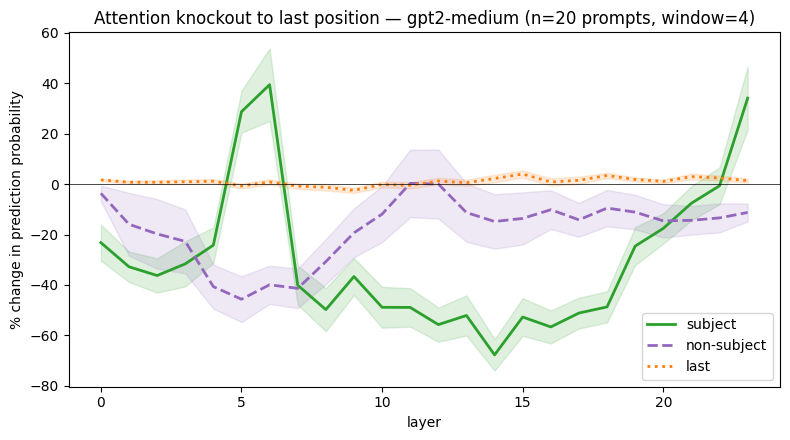


Layer with the largest mean drop in P(answer):
      subject:  layer 14   (-67.7%)
  non_subject:  layer  5   (-45.7%)
         last:  layer  9   (-2.5%)


In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(n_layers)
styles = {
    "subject":     dict(color="#2ca02c", linestyle="-",  label="subject"),
    "non_subject": dict(color="#9467bd", linestyle="--", label="non-subject"),
    "last":        dict(color="#ff7f0e", linestyle=":",  label="last"),
}
for cond, st in styles.items():
    arr = results[cond]
    mean = arr.mean(axis=0)
    sem  = arr.std(axis=0) / max(1, np.sqrt(arr.shape[0]))
    ax.plot(x, mean, linewidth=2, **st)
    ax.fill_between(x, mean - sem, mean + sem, alpha=0.15, color=st["color"])

ax.axhline(0, color="black", linewidth=0.5)
ax.set_xlabel("layer")
ax.set_ylabel("% change in prediction probability")
ax.set_title(f"Attention knockout to last position — {MODEL_NAME} "
             f"(n={arr.shape[0]} prompts, window={window})")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("figure2_reproduction.png", dpi=150)
plt.show()

print("\nLayer with the largest mean drop in P(answer):")
for k, arr in results.items():
    mean = arr.mean(axis=0)
    L = int(np.argmin(mean))
    print(f"  {k:>11}:  layer {L:>2}   ({mean[L]:+.1f}%)")

## 8. Download the figure

Right-click `figure2_reproduction.png` in the Colab file browser → Download.
Or run:
```python
from google.colab import files
files.download("figure2_reproduction.png")
```